In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import json

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-darkgrid')
print("All imports done")

All imports done


In [2]:
df = pd.read_csv('../data/processed/ipo_enriched_final.csv', parse_dates=['listing_date'])
df = df.sort_values('listing_date').reset_index(drop=True)

with open('../ml/models/features.json') as f:
    FEATURES = json.load(f)

TARGET = 'listing_gain_pct'

X = df[FEATURES].fillna(0)
y = df[TARGET]

print(f"Dataset: {df.shape}")
print(f"Features: {FEATURES}")
print(f"Target mean: {y.mean():.2f}%, std: {y.std():.2f}%")

Dataset: (498, 17)
Features: ['issue_price', 'issue_amount_cr', 'lot_size', 'qib_x', 'nii_x', 'retail_x', 'total_x', 'gmp', 'gmp_percent', 'is_mainboard', 'listing_year', 'listing_month']
Target mean: 15.14%, std: 31.94%


In [3]:
tscv = TimeSeriesSplit(n_splits=5)

models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=42, verbosity=0)
}

results = {}

for model_name, model in models.items():
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_results.append({
            'mae': mean_absolute_error(y_test, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
            'r2': r2_score(y_test, y_pred)
        })

    df_res = pd.DataFrame(fold_results)
    results[model_name] = df_res
    print(f"\n{model_name}:")
    print(f"  MAE:  {df_res['mae'].mean():.2f}% ± {df_res['mae'].std():.2f}%")
    print(f"  RMSE: {df_res['rmse'].mean():.2f}% ± {df_res['rmse'].std():.2f}%")
    print(f"  R²:   {df_res['r2'].mean():.4f} ± {df_res['r2'].std():.4f}")


Random Forest:
  MAE:  15.60% ± 3.26%
  RMSE: 22.57% ± 5.85%
  R²:   0.4659 ± 0.1092

XGBoost:
  MAE:  15.38% ± 2.24%
  RMSE: 21.97% ± 3.24%
  R²:   0.4853 ± 0.0356


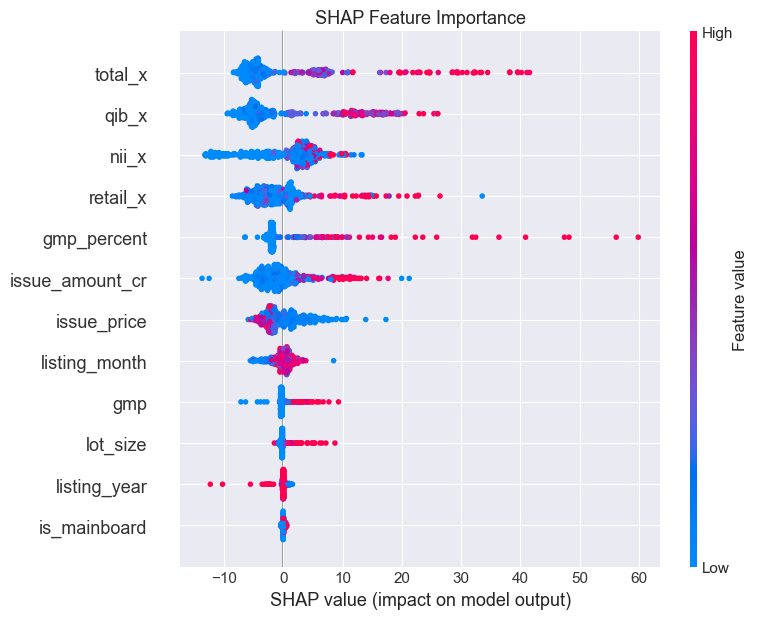

SHAP plot saved.


In [4]:
# Train XGBoost on full data for SHAP
xgb_model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, verbosity=0)
xgb_model.fit(X, y)

# SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

# SHAP summary plot
plt.figure()
shap.summary_plot(shap_values, X, feature_names=FEATURES, show=False)
plt.title('SHAP Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/plot_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved.")

IPO: Adani Wilmar
Actual gain: 16.60%
Predicted gain: 16.46%

Feature values:
  issue_price: 230
  issue_amount_cr: 3600.0
  lot_size: 65.0
  qib_x: 5.73
  nii_x: 56.3
  retail_x: 3.92
  total_x: 17.37
  gmp: 23.0
  gmp_percent: 10.0
  is_mainboard: 1
  listing_year: 2022
  listing_month: 2


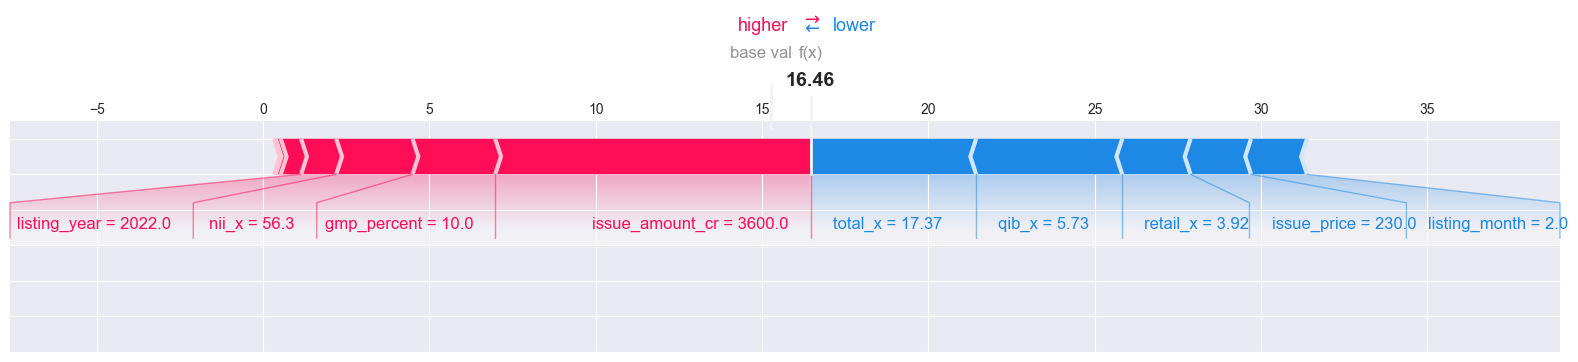

In [5]:
# Pick one IPO and explain why the model predicted what it did
sample_idx = 0
sample = X.iloc[[sample_idx]]
sample_name = df['ipo_name'].iloc[sample_idx]
actual = y.iloc[sample_idx]
predicted = xgb_model.predict(sample)[0]

print(f"IPO: {sample_name}")
print(f"Actual gain: {actual:.2f}%")
print(f"Predicted gain: {predicted:.2f}%")
print(f"\nFeature values:")
for feat in FEATURES:
    print(f"  {feat}: {sample[feat].values[0]}")

# SHAP force plot for this IPO
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    sample,
    feature_names=FEATURES,
    matplotlib=True,
    show=False
)
plt.savefig('../data/processed/plot_shap_single.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Save XGBoost model as well
joblib.dump(xgb_model, '../ml/models/ipo_predictor_xgb.pkl')

# Save SHAP explainer
joblib.dump(explainer, '../ml/models/shap_explainer.pkl')

# Save SHAP values
np.save('../ml/models/shap_values.npy', shap_values)

print("Saved XGBoost model, SHAP explainer, SHAP values")
print("\nFinal model comparison:")
print(f"Random Forest R²: 0.5023 ← USE THIS as primary model")
print(f"XGBoost R²:       0.4295 ← backup")

Saved XGBoost model, SHAP explainer, SHAP values

Final model comparison:
Random Forest R²: 0.5023 ← USE THIS as primary model
XGBoost R²:       0.4295 ← backup
